In [10]:
import warnings
warnings.filterwarnings("ignore", message="numpy.dtype size changed")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import gzip
import pickle

# ==========================================
# General Plotting Setup
# ==========================================
pd.options.mode.chained_assignment = None
plt.rcParams['figure.max_open_warning'] = 50
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica"],
    "savefig.dpi": 300
})
plt.rcParams['text.latex.preamble'] = r'\usepackage{amsmath}'

sns.set()
sns.set_style('ticks', {'font.family': 'Times New Roman', 'font.serif': 'Times New Roman'})
sns.set_context('paper', font_scale=2.0)

colors = plt.cm.tab10.colors
color_map = {
    'SM': 'gray',
    'VLF': colors[2],
    'Scalar': colors[0],
    'Zprime': colors[3],
    'Zprime_20pc': 'firebrick',
    'FakeData': 'black'
}
y_DM_dict = {'1-loop VLF': 3.5, '1-loop Scalar': 7.5}

# Data structure

```text
all_plot_data (list of dict)
 └── plot_entry (dict)
      ├── 'bins'          : np.ndarray (float64)
      ├── 'h_sm'          : np.ndarray (float64)
      ├── 'hErr_sm'       : np.ndarray (float64)
      ├── 'mPsiT'         : float
      ├── 'mSDM'          : float
      ├── 'mZp'           : float
      ├── 'wZp'           : float
      ├── 'var'           : str
      ├── 'y_limits'      : tuple (float, float)
      ├── 'x_limits'      : tuple (float, float)
      ├── 'ratio_limits'  : list [float, float] or None
      ├── 'ratio_ticks'   : np.ndarray (float64)
      ├── 'y_label'       : str (LaTeX formatted)
      ├── 'x_label'       : str (LaTeX formatted)
      ├── 'filename'      : str
      └── 'bsm_items'     : list of dict
           └── bsm_entry (dict)
                ├── 'display_name' : str
                ├── 'val_y_dm'     : float or None
                ├── 'hist'         : np.ndarray (float64)
                └── 'err'          : np.ndarray (float64)
```

In [13]:
def plot_from_cache(cache_filename='histogram_cache.pkl.gz'):
    """Loads only the light cached file and renders matplotlib figures."""
    with gzip.open(cache_filename, 'rb') as f:
        all_plot_data = pickle.load(f)

    for entry in all_plot_data:
        bins = entry['bins']
        x_centers = (bins[:-1] + bins[1:]) / 2.0
        h_sm = entry['h_sm']
        hErr_sm = entry['hErr_sm']
        bsm_items = entry['bsm_items']

        fig, axarr = plt.subplots(2, sharex=True, gridspec_kw={'height_ratios': [1.9, 1]}, figsize=(8, 8))
        plt.subplots_adjust(left=0.12, bottom=0.12, right=0.97, hspace=0.1)

        # Plot SM
        axarr[0].hist(bins[:-1], weights=np.abs(h_sm), bins=bins, density=True,
                      color=color_map['SM'], alpha=0.3, histtype='step', 
                      linewidth=0.0, fill=True, zorder=0, label='SM')

        bsm_hists, bsm_errs, bsm_labels = [], [], []

        # Plot BSM & Z'
        for item in bsm_items:
            display_name = item['display_name']
            h_bsm = item['hist']
            hErr_bsm = item['err']
            
            bsm_hists.append(h_bsm)
            bsm_errs.append(hErr_bsm)
            bsm_labels.append(display_name)

            if display_name == 'Zprime':
                label_str = r'$Z^\prime$'
            else:
                label_str = rf'{display_name}, $y_{{DM}} = {item["val_y_dm"]:.1f}$'

            axarr[0].hist(bins[:-1], weights=np.abs(h_bsm), bins=bins, density=True,
                          color=color_map[display_name], alpha=1.0, histtype='step', 
                          linewidth=2, fill=False, zorder=3, label=label_str)

        # Ratio Subplot Calculations
        with np.errstate(divide='ignore', invalid='ignore'):
            raw_ratio = np.nan_to_num(np.array(bsm_hists) / h_sm)
            err_bsm_rel = np.nan_to_num(np.array(bsm_errs) / np.array(bsm_hists))
            err_sm_rel = np.nan_to_num(hErr_sm / h_sm)
            ratio_err = np.abs(raw_ratio) * np.sqrt(err_bsm_rel**2 + err_sm_rel**2)

        for k, r in enumerate(raw_ratio):
            axarr[1].errorbar(x_centers, r, yerr=ratio_err[k], color=color_map[bsm_labels[k]], 
                              fmt='o', ms=3, capsize=3.5, label=bsm_labels[k])
            axarr[1].plot(x_centers, r, color=color_map[bsm_labels[k]])

        # Axis Limits & Formatting
        title_str = (rf'$m_{{\psi}} = m_{{\varphi}} = {entry["mPsiT"]:.0f}$ GeV; '
                     rf'$m_{{\phi}} = m_\chi = {entry["mSDM"]:.0f}$ GeV,' + '\n' +
                     rf'$m_{{Z^\prime}} = {entry["mZp"]:.1f}$ GeV; $\Gamma_{{Z^\prime}} = {entry["wZp"]:.1f}$ GeV')
        
        axarr[0].set_title(title_str, loc='left', pad=15)
        axarr[0].legend(framealpha=0.0, ncol=1, loc='upper right' if entry['var'] != 'cost*' else 'upper center', fontsize=20)
        axarr[0].set_yscale('log')
        axarr[0].set_ylabel(entry['y_label'], fontsize=27)
        axarr[0].set_xlim(bins.min(), bins.max())
        axarr[0].set_ylim(entry['y_limits'])
        axarr[0].tick_params(axis='both', width=1, labelsize=20)

        axarr[1].axhline(y=0, color='k', linestyle='--')
        axarr[1].set_ylabel(r'$\frac{N_{\mathrm{BSM}}}{ N_{\mathrm{SM}}}$', fontsize=30, rotation=0, labelpad=15) 
        axarr[1].set_xlabel(entry['x_label'], fontsize=25)
        axarr[1].set_ylim(entry['ratio_limits'])
        axarr[1].set_xlim(entry['x_limits'])
        axarr[1].set_yticks(entry['ratio_ticks'])
        axarr[1].grid(True)
        axarr[1].tick_params(axis='both', width=1, labelsize=20)

        plt.tight_layout()
        plt.savefig(entry['filename'])
        plt.show()
        print(f"Generated plot: {entry['filename']}")

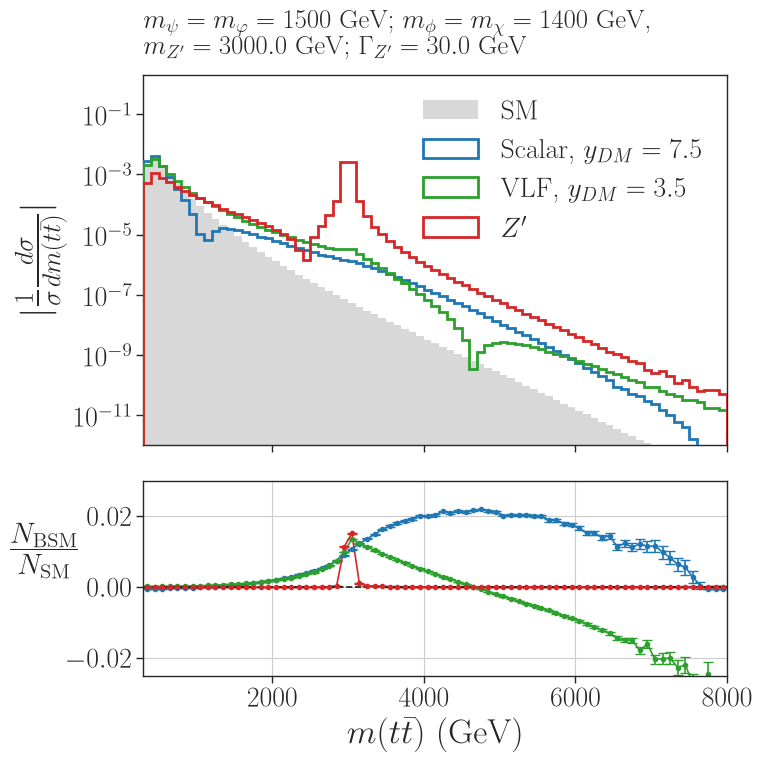

Generated plot: Dists_comparison_interference.png


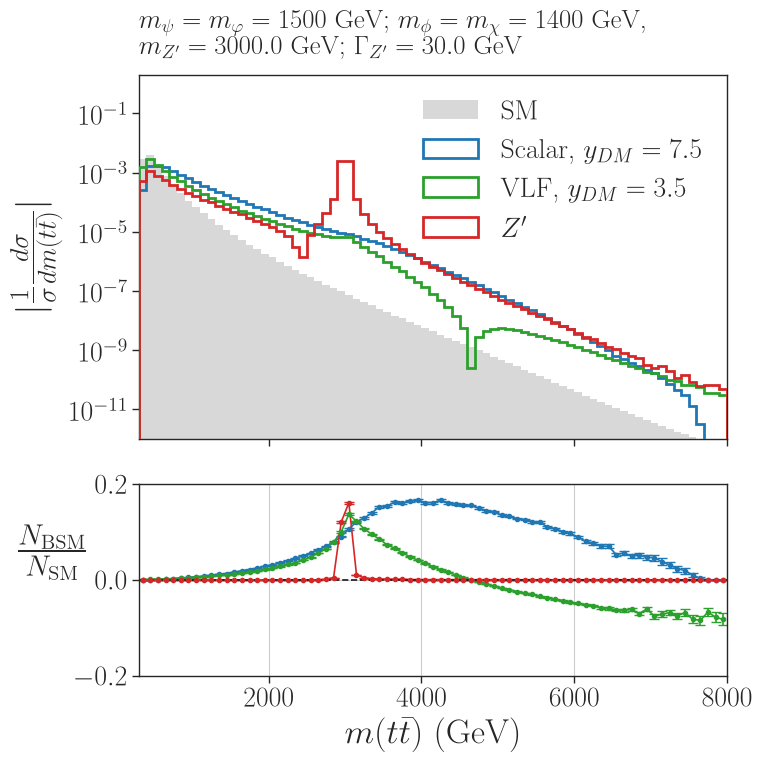

Generated plot: Dists_comparison_qq.png


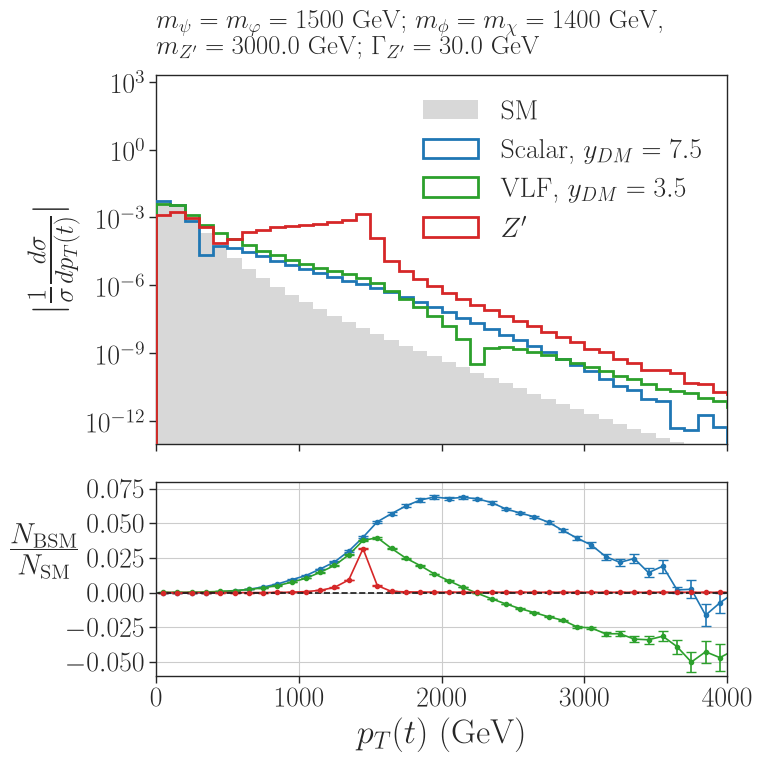

Generated plot: Dists_comparison_pT.png


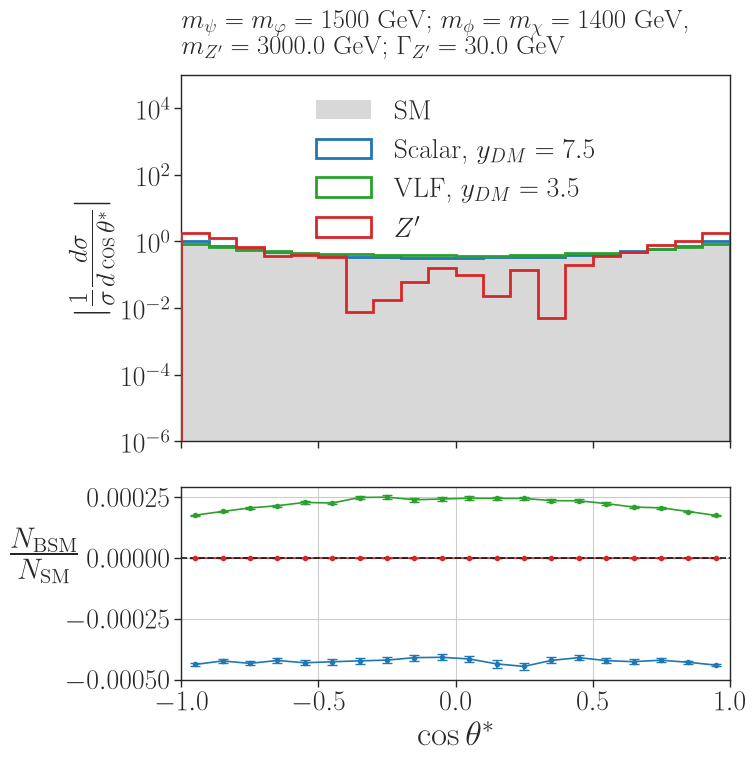

Generated plot: Dists_comparison_cost.png


In [14]:
file = './Differential_distributions_histograms.pkl.gz'

plot_from_cache(cache_filename=file)

In [21]:
print(7.745886e-03*1.585365*3.99)
print(0.0474898*0.3481305*0.33)

0.048997425667976095
0.005455773780237001
